# (Ignore warnings)

In [129]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Includes

In [130]:

from ucimlrepo import fetch_ucirepo, list_available_datasets
from sklearn.datasets import fetch_openml
from tabulate import tabulate


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

Carreguem dataset, guardem variables a X, variable objectiu a y i dataset complet a heart_disease_df

In [131]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 50)

df = pd.read_csv("heart.csv")

positions = [(87, 'thal'), (166, 'ca'), (192, 'ca'), (266, 'thal'), (287, 'ca'), (302, 'ca')]

for pos in positions:
    row_index, col_name = pos
    df.loc[row_index, col_name] = np.nan
display(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.300,0,0.000,1.000,1
1,37,1,2,130,250,0,1,187,0,3.500,0,0.000,2.000,1
2,41,0,1,130,204,0,0,172,0,1.400,2,0.000,2.000,1
3,56,1,1,120,236,0,1,178,0,0.800,2,0.000,2.000,1
4,57,0,0,120,354,0,1,163,1,0.600,2,0.000,2.000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.200,1,0.000,3.000,0
299,45,1,3,110,264,0,1,132,0,1.200,1,0.000,3.000,0
300,68,1,0,144,193,1,1,141,0,3.400,1,2.000,3.000,0
301,57,1,0,130,131,0,1,115,1,1.200,1,1.000,3.000,0


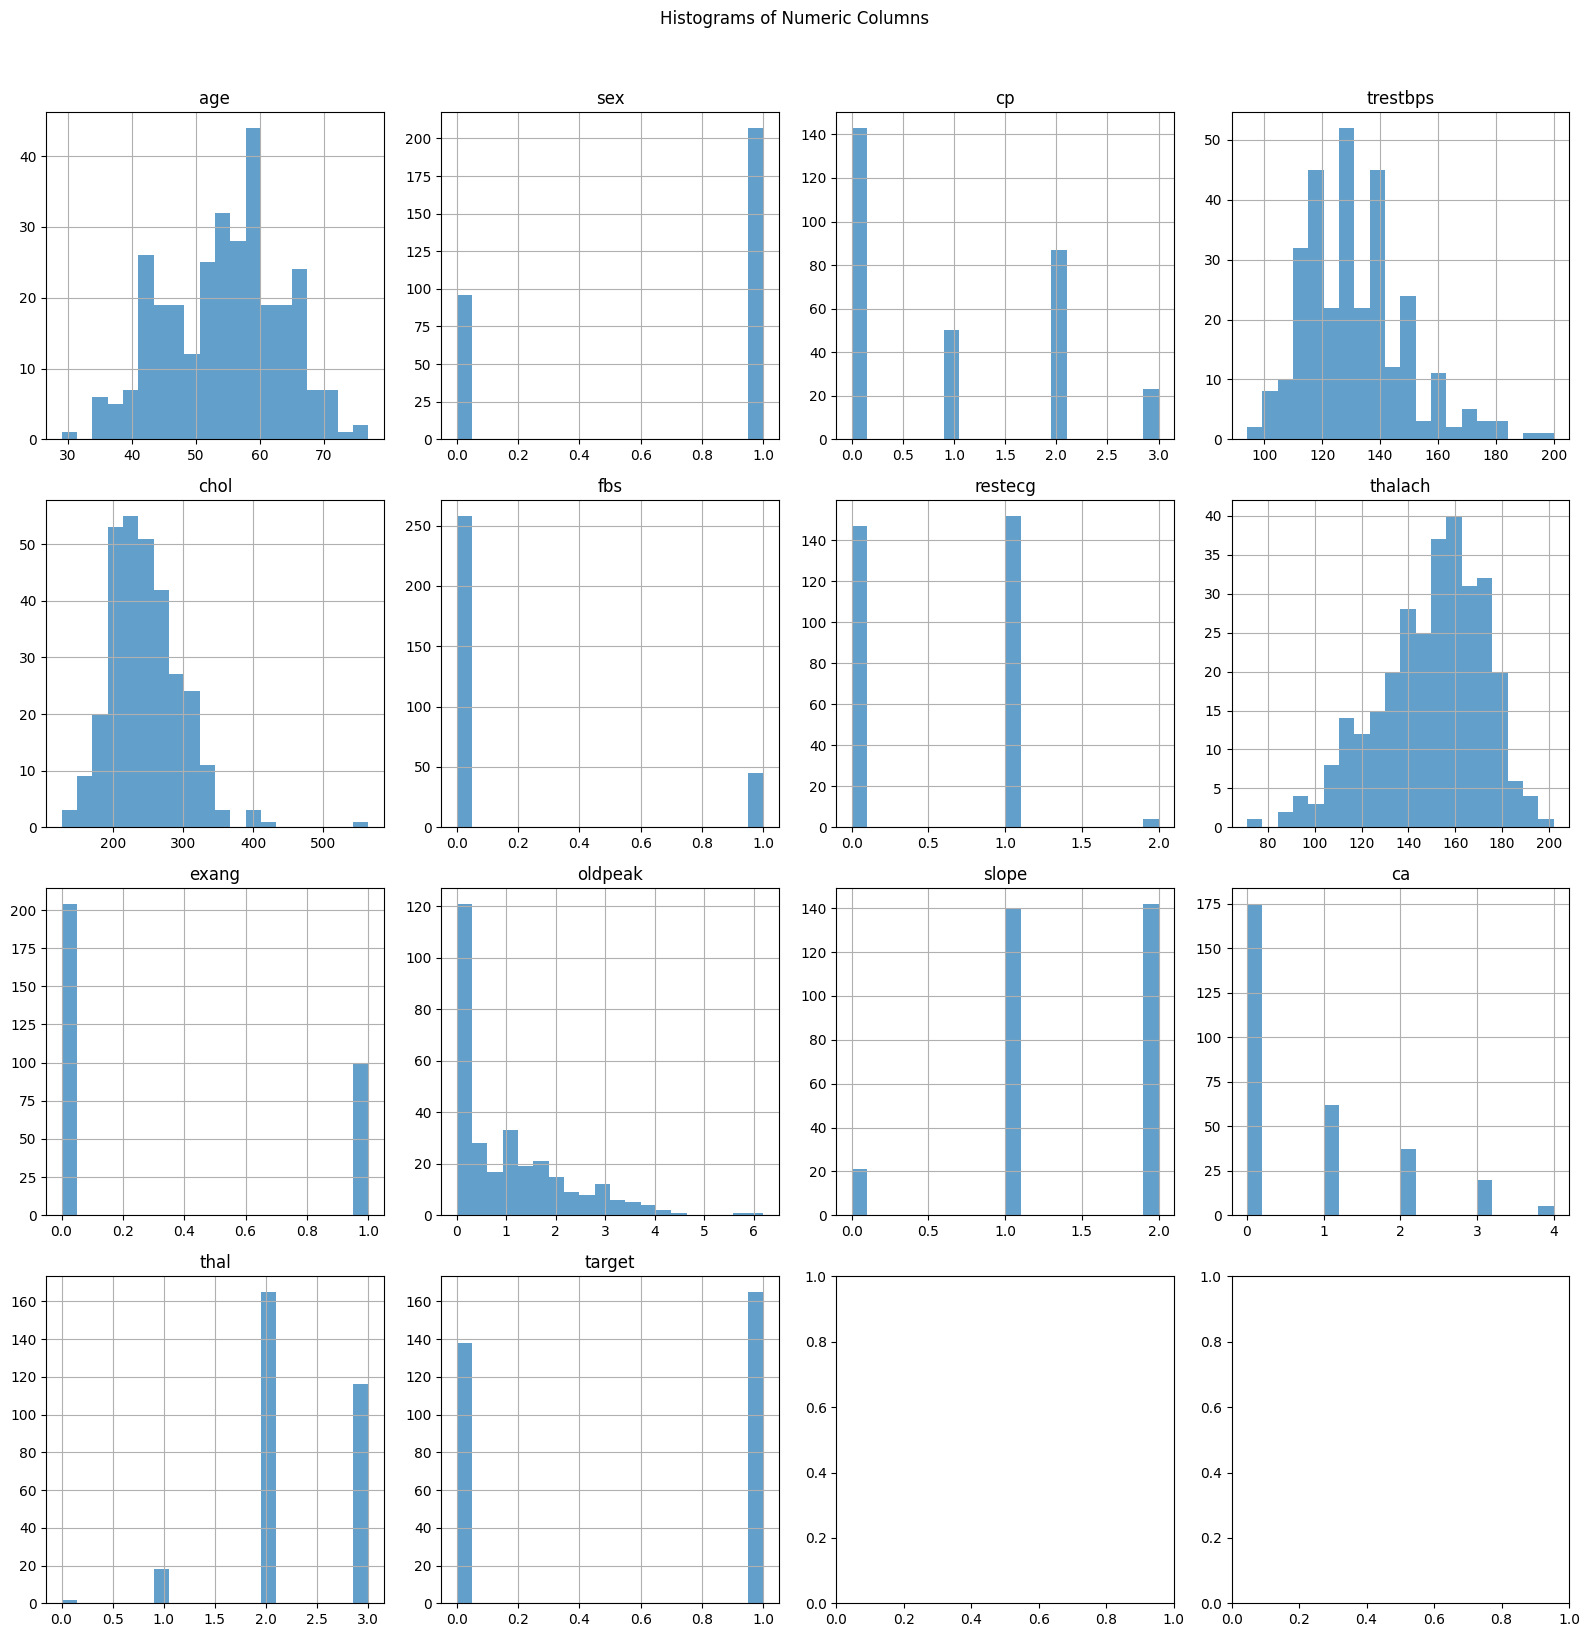

In [132]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Histograms of Numeric Columns', y=1.02)

for i, column in enumerate(df.columns):
    ax = axes[i // 4, i % 4]
    df[column].hist(ax=ax, bins=20, alpha=0.7)
    ax.set_title(column)

plt.tight_layout()
plt.show()


<Axes: >

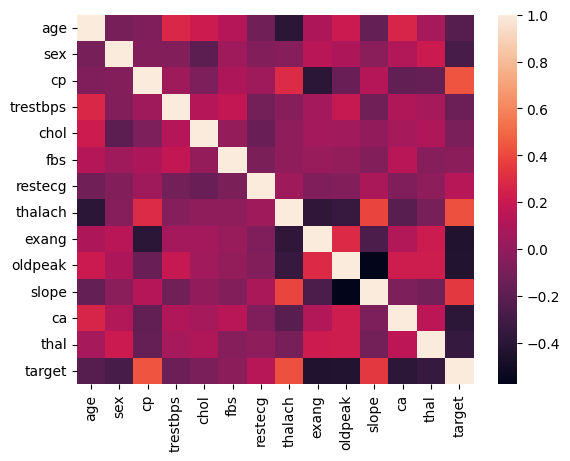

In [133]:
sns.heatmap((df).corr())

Visualitzem la quantitat de NaNs que tenim en la base de dades per columna.

In [134]:
nan_counts = df.isna().sum()
print("Nombre de NaN per columna:")
display(nan_counts)

Nombre de NaN per columna:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Ara mostrem les files que contenen NaN en algun atribut.

In [135]:
display(df[df.isna().any(axis=1)])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,46,1,1,101,197,1,1,156,0,0.000,2,0.000,NaN,1
166,67,1,0,120,229,0,0,129,1,2.600,1,NaN,3.000,0
192,54,1,0,120,188,0,1,113,0,1.400,1,NaN,3.000,0
266,55,0,0,180,327,0,2,117,1,3.400,1,0.000,NaN,0
287,57,1,1,154,232,0,0,164,0,0.000,2,NaN,2.000,0
302,57,0,1,130,236,0,0,174,0,0.000,1,NaN,2.000,0


### Preprocessing Pipeline:

* Standaritzar
* Normalitzar
* Tractar NaNs

In [136]:
class NaNsImputer(BaseEstimator, TransformerMixin):
     
    def fit(self, X):
        return self
    
    def transform(self, X):
        imputer = SimpleImputer(strategy='mean')
        X['ca'] = imputer.fit_transform(X[['ca']])
        X['thal'] = imputer.fit_transform(X[['thal']])
        return X
    
class Normalizer(BaseEstimator, TransformerMixin):
    
    def fit(self, X):
        return self
    
    def transform(self, X):
        scaler = MinMaxScaler()
        X_transformed = scaler.fit_transform(X)
        return pd.DataFrame(X_transformed, columns=X.columns)


In [137]:
pipe = Pipeline([
    ("NnNsImputer", NaNsImputer()),
    ("Normalizer", Normalizer())
])

df = pipe.fit_transform(df)
print(f'Number of NaNs: {df.isna().sum().sum()}')
df

Number of NaNs: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.708,1.000,1.000,0.481,0.244,1.000,0.000,0.603,0.000,0.371,0.000,0.000,0.333,1.000
1,0.167,1.000,0.667,0.340,0.283,0.000,0.500,0.885,0.000,0.565,0.000,0.000,0.667,1.000
2,0.250,0.000,0.333,0.340,0.178,0.000,0.000,0.771,0.000,0.226,1.000,0.000,0.667,1.000
3,0.562,1.000,0.333,0.245,0.251,0.000,0.500,0.817,0.000,0.129,1.000,0.000,0.667,1.000
4,0.583,0.000,0.000,0.245,0.521,0.000,0.500,0.702,1.000,0.097,1.000,0.000,0.667,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.583,0.000,0.000,0.434,0.263,0.000,0.500,0.397,1.000,0.032,0.500,0.000,1.000,0.000
299,0.333,1.000,1.000,0.151,0.315,0.000,0.500,0.466,0.000,0.194,0.500,0.000,1.000,0.000
300,0.812,1.000,0.000,0.472,0.153,1.000,0.500,0.534,0.000,0.548,0.500,0.500,1.000,0.000
301,0.583,1.000,0.000,0.340,0.011,0.000,0.500,0.336,1.000,0.194,0.500,0.250,1.000,0.000


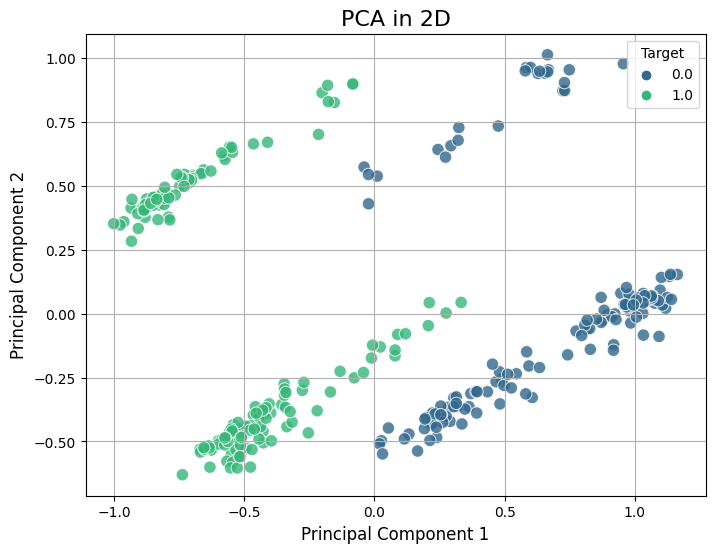

In [143]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

# Create a scatter plot with seaborn for better aesthetics
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['target'], palette='viridis', edgecolor='w', s=80, alpha=0.8)

# Customize plot
plt.title('PCA in 2D', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Target', loc='best', fontsize=10)
plt.grid(True)

# Show the plot
plt.show()